<a href="https://colab.research.google.com/github/bmil-ssu/advanced_ann/blob/main/2024/Code/Advanced_Ann_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch_optimizer

# 라이브러리 호출 및 시드 고정 (호출 함수만 추가 가능, 시드 변경 불가)

# 데이터 로드 및 전처리 (수정 불가)

# 모델 학습 (수정 불가)

# valid 성능 평가 (수정 불가)

# Test 성능 평가 (수정 불가)

Test Accuracy: 0.7934
Precision: 0.8142
Recall: 0.7602
F1-Score: 0.7863


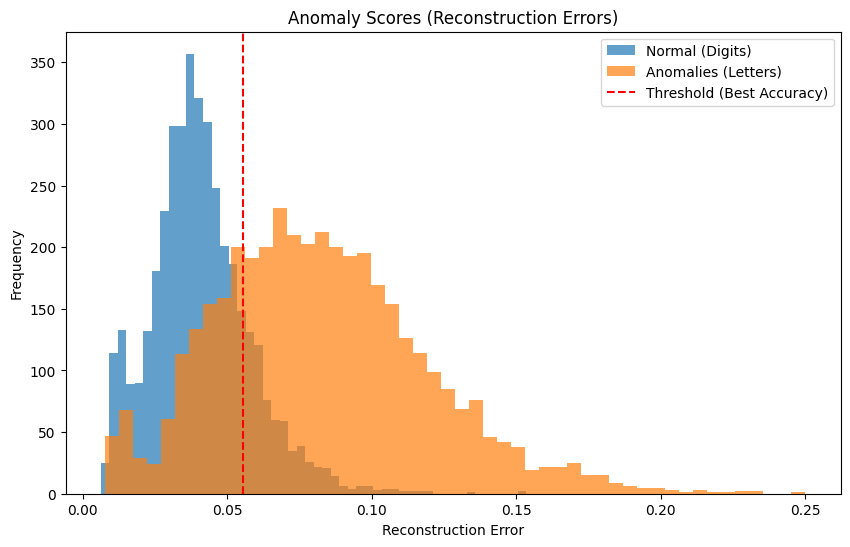

In [ ]:
# 테스트 데이터에 대한 성능 평가
test_combined_dataset = TensorDataset(torch.tensor(X_test_combined), torch.tensor(y_test_combined))
test_combined_loader = DataLoader(test_combined_dataset, batch_size=batch_size)

# 테스트 데이터에 대한 재구성 오차 및 라벨 계산
test_combined_errors, y_test_combined_actual = evaluate(test_combined_loader)

# 임계값을 이용하여 예측 라벨 생성
y_test_pred = (test_combined_errors > best_threshold).astype(int)

# 테스트 데이터에 대한 성능 평가
test_accuracy = accuracy_score(y_test_combined_actual, y_test_pred)
test_precision = precision_score(y_test_combined_actual, y_test_pred, zero_division=0)
test_recall = recall_score(y_test_combined_actual, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test_combined_actual, y_test_pred, zero_division=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Anomaly Score (재구성 오차) 그래프 시각화
plt.figure(figsize=(10, 6))
plt.hist(test_digits_errors, bins=50, alpha=0.7, label='Normal (Digits)')
plt.hist(test_letters_errors, bins=50, alpha=0.7, label='Anomalies (Letters)')
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Threshold (Best Accuracy)')
plt.title('Anomaly Scores (Reconstruction Errors)')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.show()
